# 08. 고급 시각화 - 실습 문제

## 실습 안내
- 총 8개 문제 (총 100점)
- Subplot, 이중 축, 시계열 시각화 연습
- 복합 차트와 고급 커스터마이징

## 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
production_df = pd.read_csv('../data/05_production.csv', encoding='utf-8-sig')
sensor_df = pd.read_csv('../data/08_sensor_data.csv', encoding='utf-8-sig')

# 날짜 변환
production_df['production_date'] = pd.to_datetime(production_df['production_date'])
sensor_df['measurement_time'] = pd.to_datetime(sensor_df['measurement_time'])

# 불량률 계산
production_df['defect_rate'] = (
    production_df['defect_quantity'] / production_df['actual_quantity'] * 100
).round(2)

print("데이터 로드 완료!")

데이터 로드 완료!


In [2]:
from koreanize_matplotlib import koreanize
koreanize()

---
## 문제 1: 2x2 Subplot - 제품 분석 대시보드 (15점)

**요구사항**:
2x2 subplot을 구성하여 제품 분석 대시보드 생성

1. **[0, 0]**: 제품별 총 생산량 막대 그래프
   - 색상: 'steelblue', 테두리: 'black'
   - 제목: '제품별 총 생산량'

2. **[0, 1]**: 제품별 평균 불량률 가로 막대 그래프
   - 색상: 'coral', 테두리: 'black'
   - 제목: '제품별 평균 불량률'

3. **[1, 0]**: 제품별 평균 사이클 타임 막대 그래프
   - 색상: 'lightgreen', 테두리: 'black'
   - 제목: '제품별 평균 사이클 타임'

4. **[1, 1]**: 제품별 생산 건수 막대 그래프
   - 색상: 'plum', 테두리: 'black'
   - 제목: '제품별 생산 건수'

5. Figure 크기: (14, 10)
6. 전체 제목: '제품 분석 대시보드'

**힌트**: `fig, axes = plt.subplots(2, 2)`, `axes[i, j]`

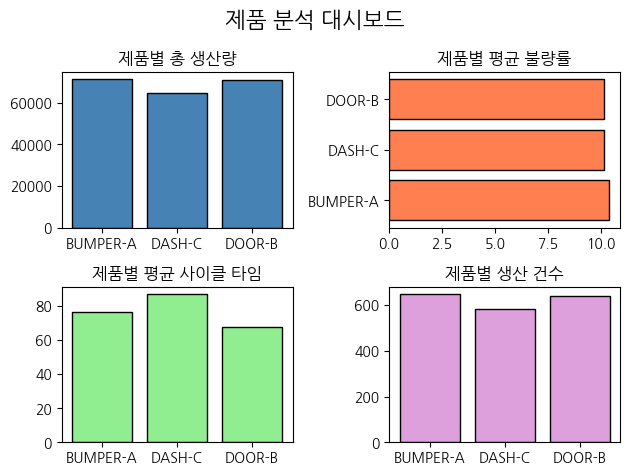

In [17]:
# 여기에 코드 작성
daily_stats = production_df.groupby('product_code').agg({'actual_quantity' : 'sum',
                                                            'defect_rate' : 'mean',
                                                           'cycle_time' : 'mean',
                                                        'product_code' : 'count'})

fig, axes = plt.subplots(2,2)

axes[0,0].bar(daily_stats.index, daily_stats['actual_quantity'], color = 'steelblue', edgecolor='black')
axes[0,0].set_title('제품별 총 생산량')
axes[0,1].barh(daily_stats.index, daily_stats['defect_rate'], color = 'coral', edgecolor='black')
axes[0,1].set_title( '제품별 평균 불량률')
axes[1,0].bar(daily_stats.index, daily_stats['cycle_time'], color = 'lightgreen', edgecolor = 'black')
axes[1,0].set_title('제품별 평균 사이클 타임')
axes[1,1].bar(daily_stats.index, daily_stats['product_code'], color = 'plum', edgecolor = 'black')
axes[1,1].set_title('제품별 생산 건수')

plt.suptitle('제품 분석 대시보드', fontsize = 16)
plt.tight_layout()
plt.show()

---
## 문제 2: 이중 y축 - 일별 생산량 vs 불량률 (15점)

**요구사항**:
1. 일별 총 생산량과 평균 불량률 집계 (처음 30일)
2. 이중 y축 차트 생성:
   - 왼쪽 축: 생산량 (선 그래프, 색상: 'steelblue', 마커: 'o')
   - 오른쪽 축: 불량률 (선 그래프, 색상: 'red', 마커: 's', 점선)
3. 각 축의 레이블 색상을 선 색상과 동일하게
4. 제목: '일별 생산량 vs 불량률 (30일)'
5. 범례 결합하여 표시
6. Figure 크기: (14, 6)

**힌트**: `ax1.twinx()`, `lines = line1 + line2`

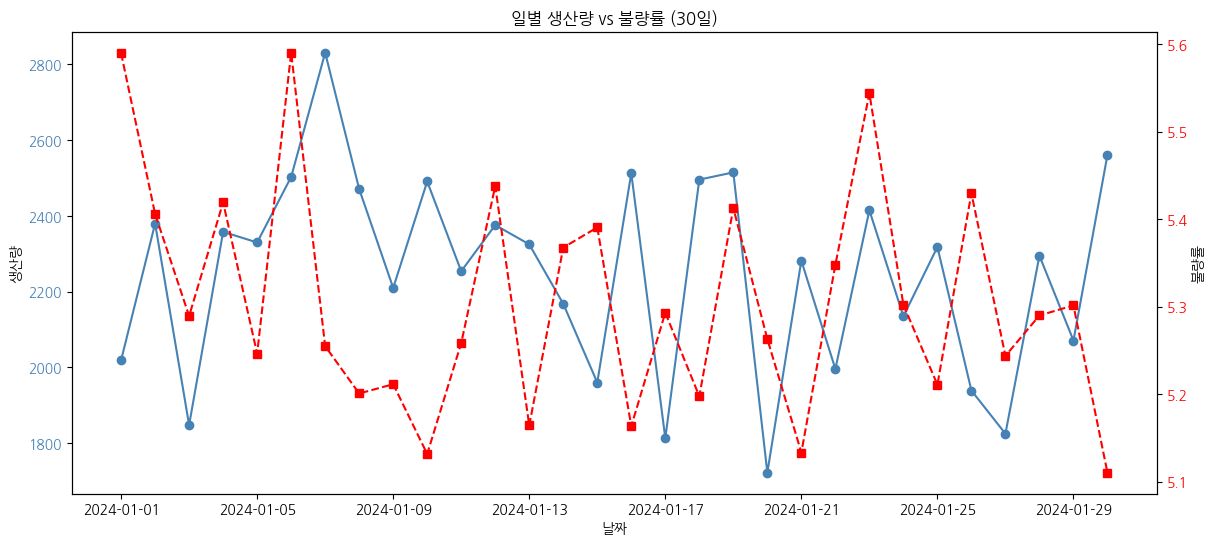

In [20]:
# 여기에 코드 작성
daily_stats = production_df.groupby('production_date').agg({'actual_quantity' : 'sum',
                                                            'defect_rate' : 'mean'}).head(30)
                                                         
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(daily_stats.index, daily_stats['actual_quantity'], color = 'steelblue', marker = 'o')
ax1.tick_params(axis='y', labelcolor = 'steelblue')
ax1.set_xlabel('날짜')
ax1.set_ylabel('생산량')


ax2 = ax1.twinx()
ax2.plot(daily_stats.index, daily_stats['defect_rate'], color = 'red', marker = 's', linestyle = '--')
ax2.tick_params(axis='y', labelcolor = 'red')
ax2.set_ylabel('불량률')


plt.title('일별 생산량 vs 불량률 (30일)')
plt.show()

---
## 문제 3: 이중 축 + 막대 - 교대조별 생산량 vs 불량률 (15점)

**요구사항**:
1. 교대조별 총 생산량과 평균 불량률 집계
2. 이중 y축 차트:
   - 왼쪽 축: 생산량 (막대 그래프, 색상: 'skyblue', alpha=0.7)
   - 오른쪽 축: 불량률 (선 그래프, 색상: 'red', 마커: 'o', linewidth=2.5)
3. 제목: '교대조별 생산량 vs 불량률'
4. 각 축에 별도 범례
5. Figure 크기: (10, 6)

**힌트**: 막대는 ax1.bar(), 선은 ax2.plot()

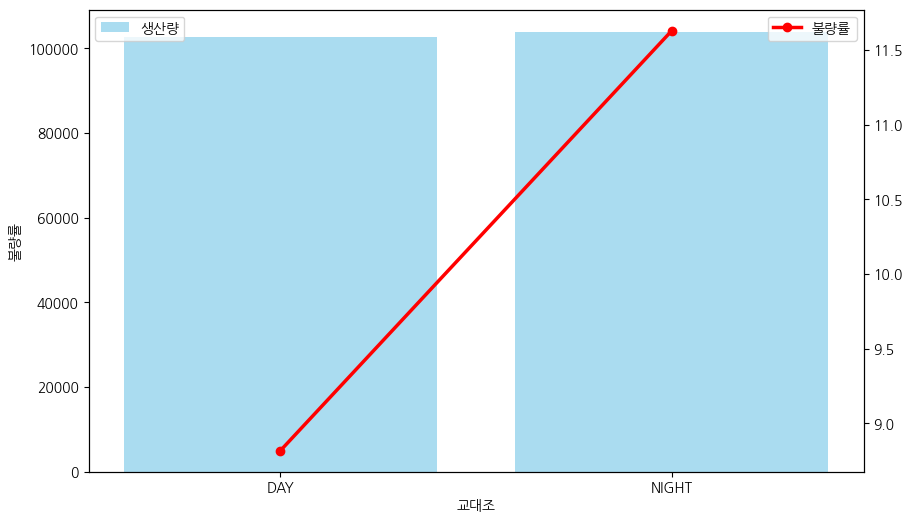

In [24]:
# 여기에 코드 작성
shift_prod = production_df.groupby('shift').agg({'actual_quantity' : 'sum',
                                    'defect_rate' : 'mean'})

fig, ax1 = plt.subplots(figsize = (10,6))

ax1.bar(shift_prod.index, shift_prod['actual_quantity'], color = 'skyblue', alpha = 0.7, label = '생산량')
ax1.set_xlabel('교대조')
ax1.set_ylabel('생산량')
#ax1.tick_params(axis='y', labelcolor = 'skyblue')
ax1.legend(loc= 'upper left')

ax2 = ax1.twinx()
ax2.plot(shift_prod.index, shift_prod['defect_rate'], color = 'red', marker = 'o', linewidth = 2.5, label = '불량률')
ax1.set_ylabel('불량률')
#ax2.tick_params(axis='y', labelcolor = 'red')
ax2.legend(loc = 'upper right')

plt.show()

---
## 문제 4: 이동평균 - 일별 불량률 추이 (15점)

**요구사항**:
1. 일별 평균 불량률 집계
2. 3일 이동평균 계산
3. 7일 이동평균 계산
4. 한 차트에 3개 선 그래프 표시:
   - 실제값: 회색, alpha=0.5, 마커='o', markersize=3, label='실제값'
   - 3일 MA: 'steelblue', linewidth=2, label='3일 이동평균'
   - 7일 MA: 'red', linewidth=2, label='7일 이동평균'
5. 제목: '일별 불량률 추이 및 이동평균'
6. 범례, 격자 추가
7. Figure 크기: (14, 6)

**힌트**: `rolling(window=n).mean()`

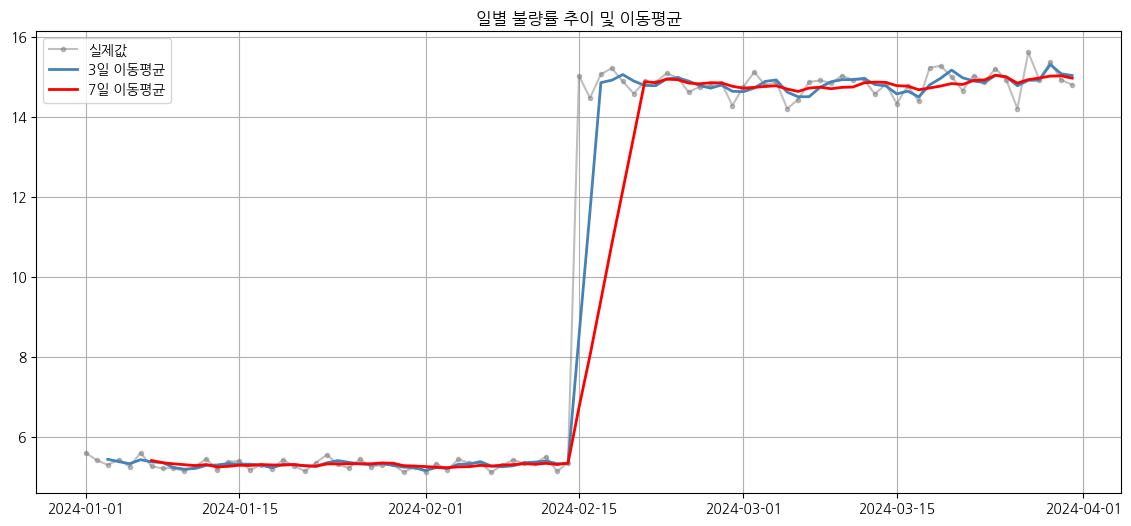

In [27]:
# 여기에 코드 작성
daily_defect = production_df.groupby('production_date')['defect_rate'].mean()
ma_3 = daily_defect.rolling(window=3).mean()
ma_7 = daily_defect.rolling(window=7).mean()

plt.figure(figsize = (14,6))

plt.plot(daily_defect.index, daily_defect.values, color = 'gray', alpha=0.5, marker='o', markersize=3, label='실제값')
plt.plot(ma_3.index, ma_3.values, color = 'steelblue', linewidth=2, label='3일 이동평균')
plt.plot(ma_7.index, ma_7.values, color = 'red', linewidth=2, label='7일 이동평균')

plt.title('일별 불량률 추이 및 이동평균')
plt.grid(True)
plt.legend()
plt.show()


---
## 문제 5: 센서 데이터 시계열 (4개 subplot) (10점)

**요구사항**:
1. 센서 데이터에서 첫 번째 설비의 첫 날 데이터 추출
2. 4x1 subplot 구성 (세로로 쌓기, sharex=True):
   - 온도 (색상: 'red', 제목: 'Temperature')
   - 압력 (색상: 'blue', 제목: 'Pressure')
   - 진동 (색상: 'green', 제목: 'Vibration')
   - 전류 (색상: 'orange', 제목: 'Current')
3. 모든 subplot에 격자 추가
4. 전체 제목: '설비 센서 데이터 시계열'
5. Figure 크기: (14, 10)

**힌트**: `plt.subplots(4, 1, sharex=True)`

In [41]:
# 여기에 코드 작성
first_equipment = sensor_df['equipment_id'][0]
first_date = sensor_df['measurement_time'].dt.date[0]
sensor_sample = sensor_df.loc[(sensor_df['equipment_id'] ==first_equipment) & (sensor_df['measurement_time'].dt.date == first_date)]

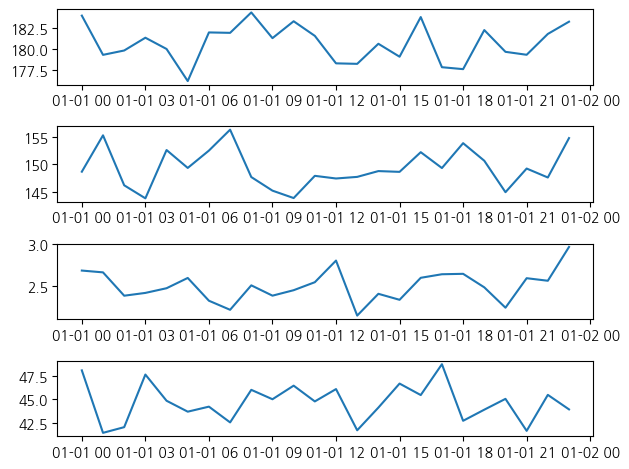

In [42]:
plt.subplot(4,1,1)
plt.plot(sensor_sample['measurement_time'], sensor_sample['temperature'])

plt.subplot(4,1,2)
plt.plot(sensor_sample['measurement_time'], sensor_sample['pressure'])

plt.subplot(4,1,3)
plt.plot(sensor_sample['measurement_time'], sensor_sample['vibration'])

plt.subplot(4,1,4)
plt.plot(sensor_sample['measurement_time'], sensor_sample['current'])

plt.tight_layout()
plt.show()

---
## 문제 6: 주석과 화살표 - 최대/최소값 표시 (10점)

**요구사항**:
1. 일별 평균 불량률 (처음 30일) 선 그래프
2. 최대값에 주석 추가:
   - 텍스트: '최고 불량률\nX.XX%'
   - 빨간색 화살표
   - 노란색 박스 배경 (alpha=0.7)
3. 평균값 수평선 추가 (빨간 점선)
4. 제목: '일별 불량률 추이 (최대값 강조)'
5. 범례, 격자 추가
6. Figure 크기: (14, 6)

**힌트**: `annotate()`, `axhline()`

In [ ]:
# 여기에 코드 작성


---
## 문제 7: 막대 위 값 표시 - 제품별 생산량 (10점)

**요구사항**:
1. 제품별 총 생산량 막대 그래프
2. 각 막대 위에 생산량 숫자 표시:
   - 천 단위 콤마 포함
   - 가운데 정렬
   - 볼드체
3. 커스텀 색상 사용
4. 막대 테두리: 검은색, linewidth=1.5
5. 제목: '제품별 총 생산량 (수량 표시)'
6. 배경색: '#f9f9f9'
7. Figure 크기: (12, 6)

**힌트**: `for bar in bars:` 반복문, `bar.get_height()`, `ax.text()`

In [ ]:
# 여기에 코드 작성


---
## 문제 8: GridSpec 고급 레이아웃 (20점)

**요구사항**:
GridSpec을 사용하여 비대칭 레이아웃의 생산 현황 대시보드 구성

1. **상단 전체 (0, :)**: 일별 생산량 추이 (선 그래프)
   - 처음 30일
   - 색상: 'steelblue', 마커: 'o'
   - 제목: '일별 생산량 추이'

2. **중단 왼쪽 (1, 0)**: 교대조별 생산량 (막대)
   - 색상: ['skyblue', 'coral']
   - 제목: '교대조별 생산량'

3. **중단 오른쪽 (1, 1)**: 제품별 생산량 (막대)
   - 색상: 'lightgreen', 테두리: 'black'
   - 제목: '제품별 생산량'

4. **하단 왼쪽 (2, 0)**: 불량률 분포 (히스토그램)
   - bins=40, 색상: 'skyblue'
   - 평균선 추가 (빨간 점선)
   - 제목: '불량률 분포'

5. **하단 오른쪽 (2, 1)**: 일별 불량률 추이 (선 그래프)
   - 처음 30일
   - 색상: 'red', 마커: 'o'
   - 제목: '일별 불량률 추이'

6. Figure 크기: (16, 12)
7. 전체 제목: '생산 현황 종합 대시보드'
8. hspace=0.3, wspace=0.3

**힌트**: `GridSpec(3, 2)`, `fig.add_subplot(gs[row, col])`

In [ ]:
# 여기에 코드 작성


---
## 수고하셨습니다!

### 학습 체크리스트
- [ ] 2x2 Subplot으로 대시보드 구성
- [ ] 이중 y축으로 다른 단위 동시 표시
- [ ] 이중 축 + 막대/선 조합
- [ ] 이동평균 계산 및 시각화
- [ ] 센서 데이터 시계열 (다중 subplot)
- [ ] 주석과 화살표로 특정 값 강조
- [ ] 막대 위에 값 표시
- [ ] GridSpec으로 비대칭 레이아웃

